# FEATURE ENGINEERING

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

In [3]:
df = pd.read_csv("DATASET/titanic.csv")
df.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


In [4]:
# checking for missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Methods to handle Missing values

## 1.Mean value imputation

<Axes: xlabel='Age', ylabel='Count'>

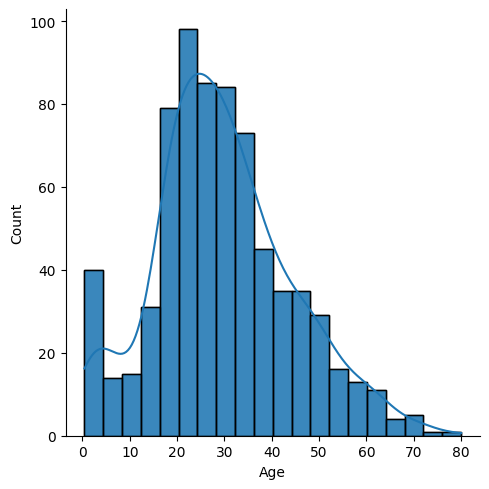

In [5]:
# 1.Mean value imputation : works well when we have a normally distributed data
sns.displot(df["Age"])
sns.histplot(df["Age"],kde=True)

In [6]:
# replace the NAN values by mean 
df["Age_mean"]=df["Age"].fillna(df["Age"].mean())
df["Age_mean"]

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age_mean, Length: 891, dtype: float64

In [7]:
df[["Age_mean","Age"]]

,Age_mean,Age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


## 2.Median imputation

In [8]:
# 2.median imputation: If we have outlier in the dataset
df["Age_Median"]=df["Age"].fillna(df["Age"].median())
df[["Age_Median","Age_mean","Age"]]

,Age_Median,Age_mean,Age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


## 3.Mode Imputation


In [9]:
# 3.mode imputation :Categorial value
df["Age_mode"]=df["Age"].fillna(df["Age"].mode())
df[["Age_mode","Age_Median","Age_mean","Age"]]

,Age_mode,Age_Median,Age_mean,Age
0,22.0,22.0,22.000000,22.0
1,38.0,38.0,38.000000,38.0
2,26.0,26.0,26.000000,26.0
3,35.0,35.0,35.000000,35.0
4,35.0,35.0,35.000000,35.0
...,...,...,...,...
886,27.0,27.0,27.000000,27.0
887,19.0,19.0,19.000000,19.0
888,NaN,28.0,29.699118,NaN
889,26.0,26.0,26.000000,26.0


In [10]:
df[df["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_mean,Age_Median,Age_mode
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,38.0,38.0,38.0
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,62.0,62.0,62.0


In [11]:
df["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [12]:
# find out the mode value
mode_value=df[df["Embarked"].notna()]["Embarked"].mode()[0]

In [13]:
df["Embarked_mode"]= df["Embarked"].fillna(mode_value)
df[["Embarked_mode","Embarked"]]

,Embarked_mode,Embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [14]:
df["Embarked_mode"].isnull().sum()

np.int64(0)

# Handling Imbalanced Dataset

In [15]:
# create a imbalanced dataset
import numpy as np
import pandas as pd 

# set a randomseed for reproducibility
np.random.seed(123)
# create a dataframe with two values
n_sample =1000
class_0_ratio =0.9
n_class_0 = int(n_sample * class_0_ratio)
n_class_1 = n_sample - n_class_0

In [16]:
n_class_1

100

In [17]:
n_class_0

900

In [18]:
# create a Dataframe 
class_0 = pd.DataFrame({
    'feature_1':np.random.normal(loc=0,scale=1,size=n_class_0),
    'feature_2':np.random.normal(loc=0,scale=1,size=n_class_0),
    'target':[0]*n_class_0
})
class_1 = pd.DataFrame({
    'feature_1':np.random.normal(loc=2,scale=1,size=n_class_1),
    'feature_2':np.random.normal(loc=2,scale=1,size=n_class_1),
    'target':[1]*n_class_1
})

In [19]:
df =pd.concat([class_0,class_1]).reset_index(drop = True)
df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [20]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

## 1.Upsampling

In [21]:
#upsampling
df_minority = df[df['target']==1]
df_majority = df[df['target']==0]

In [22]:
from sklearn.utils import resample
df_minority_upsampled =resample(df_minority,replace=True,
        n_samples =len(df_majority),random_state=42)

In [23]:
print(df_minority_upsampled.shape)
df_minority_upsampled.head()

(900, 3)


,feature_1,feature_2,target
951,1.125854,1.843917,1
992,2.196570,1.397425,1
914,1.932170,2.998053,1
971,2.272825,3.034197,1
960,2.870056,1.550485,1


In [24]:
df_upsampled =pd.concat([df_majority,df_minority_upsampled])

In [25]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

## 2.Downsampling

In [26]:
# create a imbalanced dataset
import numpy as np
import pandas as pd 

# set a randomseed for reproducibility
np.random.seed(123)
# create a dataframe with two values
n_sample =1000
class_0_ratio =0.9
n_class_0 = int(n_sample * class_0_ratio)
n_class_1 = n_sample - n_class_0

# create a Dataframe 
class_0 = pd.DataFrame({
    'feature_1':np.random.normal(loc=0,scale=1,size=n_class_0),
    'feature_2':np.random.normal(loc=0,scale=1,size=n_class_0),
    'target':[0]*n_class_0
})
class_1 = pd.DataFrame({
    'feature_1':np.random.normal(loc=2,scale=1,size=n_class_1),
    'feature_2':np.random.normal(loc=2,scale=1,size=n_class_1),
    'target':[1]*n_class_1
})

In [27]:
#Downsampling
df_minority = df[df['target']==1]
df_majority = df[df['target']==0]

In [28]:
from sklearn.utils import resample
df_majority_downsampled =resample(df_majority,replace=False,random_state=42,
                                  n_samples =len(df_minority))

In [29]:
df_majority_downsampled.shape

(100, 3)

In [30]:
df_downsampled = pd.concat([df_minority,df_majority_downsampled])
print(df_downsampled.target.value_counts())

target
1    100
0    100
Name: count, dtype: int64


# SMOTE(Synthetic Minority Oversampling Technique)

##### used to address imbalanced datasets where the minority class has significantly fewer instances than the majority class.SMOTE involves generating synthetic instances of the minority class by interpolating between existing instances

In [1]:
from sklearn.datasets import make_classification
# this is used to generate the datasets

In [3]:
X,y=make_classification(n_samples=1000,n_features=2,n_clusters_per_class=1,
                    weights=[0.90],random_state=42,n_redundant=0
                   )

In [6]:
import pandas as pd
df_1 = pd.DataFrame(X,columns=['f1','f2'])
df_2 = pd.DataFrame(y,columns=['target'])
final_df =pd.concat([df_1,df_2],axis =1)
print(final_df.head(4))
print(final_df['target'].value_counts())

         f1        f2  target
0  1.073546 -1.101339       0
1  0.755945 -1.172352       0
2  1.354479 -0.948528       0
3  3.103090  0.233485       0
target
0    896
1    104
Name: count, dtype: int64


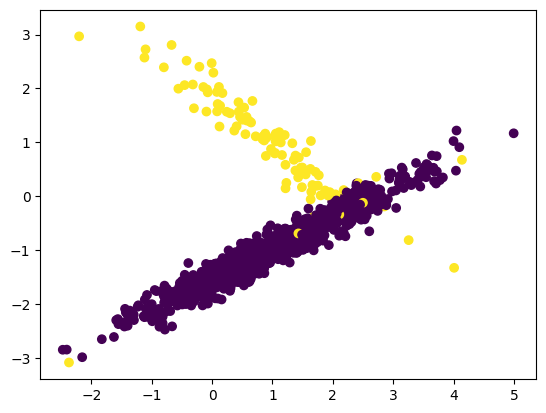

In [7]:
# visualize the dataset 
import matplotlib.pyplot as plt 
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])
plt.show()

In [8]:
# handling the imbalanced data
!pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [imblearn]━━ 1/3 [imbalanced-learn]


In [10]:
from imblearn.over_sampling import SMOTE
# transform the dataset 
oversample=SMOTE()
X,y =oversample.fit_resample(final_df[['f1','f2']],final_df['target'])


In [11]:
print(X.shape)
print(y.shape)

(1792, 2)
(1792,)


In [13]:
#count no of zeros and ones in target 
print(y[y==0])
print(y[y==1])

0      0
1      0
2      0
3      0
4      0
      ..
992    0
996    0
997    0
998    0
999    0
Name: target, Length: 896, dtype: int64
11      1
25      1
29      1
42      1
52      1
       ..
1787    1
1788    1
1789    1
1790    1
1791    1
Name: target, Length: 896, dtype: int64


In [14]:
# again create a dataset 
df_1 =pd.DataFrame(X,columns=['f1','f2'])
df_2 =pd.DataFrame(y,columns=['target'])
oversample_df =pd.concat([df_1,df_2],axis=1)

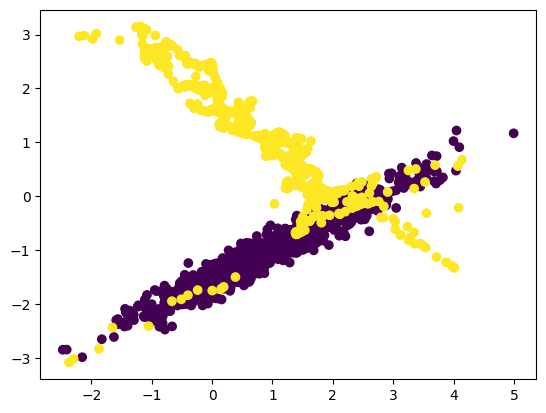

In [15]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])
plt.show()

# Handling outliers

In [16]:
# five number summary and boxplot
import numpy as np
marks =[32,14,15,89,56,56,7,9,25,6,9]
minimum,Q1,median,Q3,maximum=np.quantile(marks,[0,0.25,0.50,0.75,1.0])

In [17]:
print(minimum,Q1,median,Q3,maximum)

6.0 9.0 15.0 44.0 89.0


In [18]:
# compute the IOR
IOR =Q3-Q1
print(IOR)

35.0


In [21]:
lower_limit =Q1-1.5*(IOR)
higher_limit=Q3+1.5*(IOR)
print(lower_limit)
print(higher_limit)

-43.5
96.5


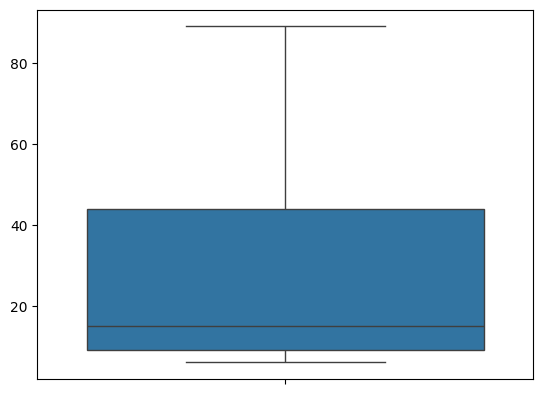

In [24]:
# visualize the data 
import seaborn as sns
sns.boxplot(marks)
plt.show()

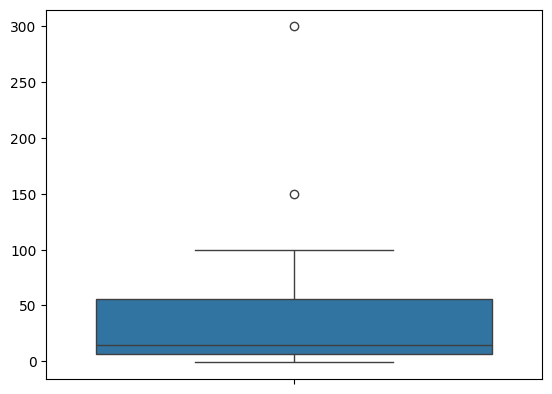

In [30]:
# performing same example using outlier 
import numpy as np
import seaborn as sns
# add the outlier 
marks_with_outliers =[32,14,15,89,56,56,7,9,25,6,9,0,100,150,300,-0.36,0.5,-1]
minimum,Q1,median,Q3,maximum=np.quantile(marks_with_outliers,[0,0.25,0.50,0.75,1.0])

# calculate IOR
IOR = Q3-Q1
lower_limit= Q1-1.5*(IOR)
higher_limit=Q3+1.5*(IOR)

#visulaize the data
sns.boxplot(marks_with_outliers)
plt.show()

# Data Encoding

* 1.Nominal/OneHotEncoding 
* 2.Lable and Ordinnal Encoding
* 3.TargetGuided and Ordinal Encoding

### Nominal/OneHot encoding

In [1]:
# Nominal/OneHot Encoding: useful on categorical data
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [4]:
#create a dataframe
df = pd.DataFrame({
    'color':['red','green','green','yellow','blue']
})
df.head(4)

,color
0,red
1,green
2,green
3,yellow


In [8]:
# create a instance of OneHot encoder
encoder = OneHotEncoder()
encoded =encoder.fit_transform(df[['color']]).toarray()

In [10]:
encoded_df =  pd.DataFrame(encoded,columns=encoder.get_feature_names_out())
encoded_df

,color_blue,color_green,color_red,color_yellow
0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0


In [11]:
# when new data comes 
encoder.transform([['blue']]).toarray()

/home/tushar/Desktop/MLandDL/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[1., 0., 0., 0.]])

In [12]:
# concatinate encoded data with orginal
pd.concat([df,encoded_df],axis=1)

,color,color_blue,color_green,color_red,color_yellow
0,red,0.0,0.0,1.0,0.0
1,green,0.0,1.0,0.0,0.0
2,green,0.0,1.0,0.0,0.0
3,yellow,0.0,0.0,0.0,1.0
4,blue,1.0,0.0,0.0,0.0


### Label Encoding

In [13]:
# Label Encoding : assign a unique numerical label to each category in the variable
df.head()

,color
0,red
1,green
2,green
3,yellow
4,blue


In [ ]:
# Label encoding implementation
from sklearn.preprocessing import LabelEncoder
ln =LabelEncoder()
label_encoded=ln.fit_transform(df[['color']])
label_encoded

### Ordinal Encoding

In [22]:
# ordinal encoding :used on categorical data that have intrinsic order or ranking,each category is assigned anumerical value based on the position
df = pd.DataFrame({
    'size':['s','l','m','xl','s','m','l']
})
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder(categories=[['s','m','l','xl']])
encoded_data =ordinal_encoder.fit_transform(df[['size']])
encoded_data

array([[0.],
       [2.],
       [1.],
       [3.],
       [0.],
       [1.],
       [2.]])

### Target guided Ordinal encoding

In [24]:
# encoding based on their relationship with the target variable
# used when large no of unique categories 
# replace the category in categorical variable based on mean,median,mode of target variable
# create a monotonic relationship between categorical value and target value
import pandas as pd 
df =pd.DataFrame({
    'city':['nashik','pune','bangalor','nashik','pune','tokyo'],
    'price':[200,100,500,600,800,1000]
})
df

,city,price
0,nashik,200
1,pune,100
2,bangalor,500
3,nashik,600
4,pune,800
5,tokyo,1000


In [26]:
# calculate the mean
mean_price =df.groupby('city')['price'].mean().to_dict()
mean_price

{'bangalor': 500.0, 'nashik': 400.0, 'pune': 450.0, 'tokyo': 1000.0}

In [29]:
# encoded data
df['city_encoded']=df['city'].map(mean_price)
df['city_encoded']

0     400.0
1     450.0
2     500.0
3     400.0
4     450.0
5    1000.0
Name: city_encoded, dtype: float64

In [32]:
df[['price','city_encoded']]
# we can use this data for model , ignoring the city names

,price,city_encoded
0,200,400.0
1,100,450.0
2,500,500.0
3,600,400.0
4,800,450.0
5,1000,1000.0
